# 8.10장 캐글 Mercari Price Suggestion Challenge

회귀로 피처 학습 ➡️ price 예측

**📌 피처들 ( 정형 + 비정형 )**


*   train_id : 데이터 id
*   name : 제품명

*   item_condition_id : 판매자가 제공하는 제품 상태

*   category_name : 카테고리 명
*   brand_name : 브랜드명



*   shipping : 배송비 무료 여부 (1 - 무료, 0 - 유료 )


*   item_description : 제품 설명


*   price : 제품 가격 ( target )


## 데이터 전처리

###📌 결측치
- brand_name : 결측치 多  849853 non-null
- category_name : 결측치 6300
- item_description : 4

###📌 회귀에서 target값 정규 분포도 매우 중요
- price log변환

###📌 피처 불균형 확인
- shipping : 비교적 균일
- item_condition_id : 1,2,3이 주, No description yet 변경 필요

###📌 단어 토큰화
- category_name : / 기준 단어 토큰화, 별도 피처 저장 ➡️ split_cat()

In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Sample_data/mercari_train.tsv',sep='\t')
print(df.shape)
df.head()

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


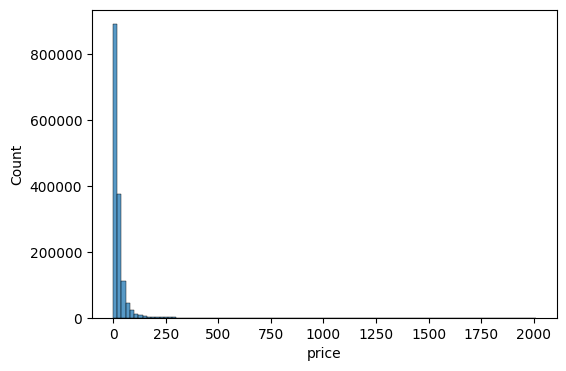

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df,bins=100)
plt.show()

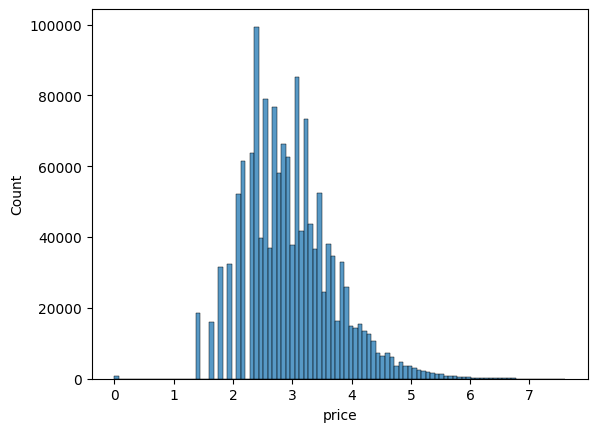

In [4]:
import numpy as np
y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df,bins=100)
plt.show()

In [5]:
df['price']=np.log1p(df['price'])
df['price'].head()

,price
0,2.397895
1,3.970292
2,2.397895
3,3.583519
4,3.806662


In [6]:
print('Shipping 값 유형 : \n',df['shipping'].value_counts())
print('item_condition_id 값 유형 : \n',df['item_condition_id'].value_counts())

Shipping 값 유형 : 
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형 : 
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [7]:
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return['Other_Null','Other_Null','Other_Null']

# split cat > 대, 중, 소 칼럼 df에 생성
df['cat_dae'],df['cat_jung'],df['cat_so'] = zip(*df['category_name'].apply(lambda x: split_cat(x)))
print('대분류 유형: \n',df['cat_dae'].value_counts())
print('중분류 개수: \n',df['cat_jung'].nunique())
print('소분류 개수: \n',df['cat_so'].nunique())

대분류 유형: 
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 개수: 
 114
소분류 개수: 
 871


In [8]:
df['brand_name']=df['brand_name'].fillna(value='Other_Null')
df['category_name']=df['category_name'].fillna(value='Other_Null')
df['item_description']=df['item_description'].fillna(value='Other_Null')
df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


## 피처 인코딩과 피처 벡터

- 선형회귀 > 원핫 인코딩

- 선형 회귀 모델 + 회귀트리 모델

In [9]:
print('brand name의 유형 건수:',df['brand_name'].nunique())
print('brand name sample 5개:\n',df['brand_name'].value_counts()[:5])


brand name의 유형 건수: 4810
brand name sample 5개:
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


In [10]:
print('name의 종류 개수:',df['name'].nunique())
print('name sample 7개: \n',df['name'][:7])

name의 종류 개수: 1225273
name sample 7개: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


📌 name
- 개별적으로 거의 고유한 상품영 ( 1225273 )
- 유형 多, 적은 단어 위주 텍스트 ➡️ CountVectorizer

📌 category_name, shipping, item_description
- category_name : cat_dae, cat_jung, cat_so
- shipping : 0,1
- item_condition_id : 1,2,3,4,5

  ➡️원핫인코딩

📌 item_description
- 평균 문자열 크기 : 145 ➡️ TfIdfVectorizer

📌 CounterVectorizer, TfidfVectorizer > fit_transform() > 희소 행렬

- X_name + X_descp > 새 데이터 셋 구성
- cat_dae,cat_jung,cat_so_vrand_name_shipping_item_condtion_id > 다 결함(scipy.sparse hstack())

  ➡️ 희소행렬 인코딩 필요 : OneHotEncoder, LabelBinarizer(sparse_out=True)

In [11]:
pd.set_option('max_colwidth',200)

# item_description의 평균 문자열 크기
print(' item_description의 평균 문자열 크기:',df['item_description'].str.len().mean())
df['item_description'][:2]

 item_description의 평균 문자열 크기: 145.71139703278507


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


In [12]:
# name CounterVectorizer 피처 벡터화
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(df.name)

# item_description TfidfVectorizer 피처 벡터화
tfidf_descp = TfidfVectorizer(max_features=50000,ngram_range=(1,3),stop_words='english')
X_descp = tfidf_descp.fit_transform(df['item_description'])
print('name vectorization shape:',X_name.shape)
print('item_description vectorization shape:',X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


In [13]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping > 희소행렬 원핫인코딩
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id= lb_brand_name.fit_transform(df['item_condition_id'])
lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping= lb_shipping.fit_transform(df['shipping'])

# cat_dae, cat_중,cat_소 > 희소행렬 원핫 인코딩
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(df['cat_so'])

In [14]:
print(type(X_brand),type(X_item_cond_id),type(X_shipping))
print('X_brand shape : {0}, X_item_cond_id_shape: {1}'.format(X_brand.shape,X_item_cond_id.shape))
print('X_shipping shape : {0}, X_cat_dae shape: {1}'.format(X_shipping.shape,X_cat_dae.shape))
print('X_cat_jung shape: {0}, X_cat_so shape: {1}'.format(X_cat_jung.shape,X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape : (1482535, 4810), X_item_cond_id_shape: (1482535, 5)
X_shipping shape : (1482535, 1), X_cat_dae shape: (1482535, 11)
X_cat_jung shape: (1482535, 114), X_cat_so shape: (1482535, 871)


In [15]:
from scipy.sparse import hstack
import gc
sparse_matrix_list = (X_name,X_descp,X_brand,X_item_cond_id,X_shipping,X_cat_dae,X_cat_jung,X_cat_so)

# hstack > 인코딩 + 벡터화 결과 결합
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse),X_features_sparse.shape)
# 메모리에서 대용량 데이터셋 삭제
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


0

## 릿지 회귀 모델 구축 및 평가

📌 Evaluation 로직 함수화
- RMSLE( Root Mean Square Logarithmic Error )
$ϵ = \sqrt{\frac{1}{n}\sum\limits_{i=1}^n(log(p_i+1)-log(a_i+1))}$

📌 price 로그 역변환

In [16]:
def rmsle(y,y_pred):
  # underflow/overflow를 막기 위해 log 아닌 log1p로 rmsle 계산
  return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred),2)))

def evaluate_org_price(y_test,preds):
  # exmpm1로 원본 복구 필요
  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)
  # rmsle > RMSLE
  rmsle_result= rmsle(y_test_exmpm,preds_exmpm)
  return rmsle_result

In [17]:
import gc
from scipy.sparse import hstack

def model_train_predict(model,matrix_list):
  # hstack > 희소행렬 결합
  X = hstack(matrix_list).tocsr()
  X_train,X_test,y_train,y_test = train_test_split(X,df['price'],test_size=0.2,random_state=156)

  # 모델 학습 및 예측
  model.fit(X_train,y_train)
  preds = model.predict(X_test)

  del X,X_train,X_test,y_train
  gc.collect()

  return preds,y_test

In [18]:
# 릿지로 회귀 예측 수행
linear_model = Ridge(solver='lsqr',fit_intercept=False)

sparse_matrix_list = (X_name,X_brand,X_item_cond_id,
                      X_shipping,X_cat_dae,X_cat_jung,X_cat_so)
linear_preds,y_test = model_train_predict(model=linear_model,matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle값 : ',evaluate_org_price(y_test,linear_preds))

sparse_matrix_list = (X_descp,X_name,X_brand,X_item_cond_id,
                      X_shipping,X_cat_dae,X_cat_jung,X_cat_so)
linear_preds,y_test = model_train_predict(model=linear_model,matrix_list=sparse_matrix_list)
print('Item Description을 포함했을 때 rmsle값 : ',evaluate_org_price(y_test,linear_preds))

Item Description을 제외했을 때 rmsle값 :  0.4983990938999374
Item Description을 포함했을 때 rmsle값 :  0.4680432471796771


## LightGBM 회귀모델 구축과 앙상블을 이용한 최종 예측 평가

❌ 40분 이상 돌려도 출력이 안되더니 노트북이 픽 꺼져서 ㅠㅠ...실행결과 출력은 못했습니다. 제 노트북 성능상 실행이 안되는 것 같습니다.... 죄송합니다..

In [ ]:
from lightgbm import LGBMRegressor

sparse_matrix_list = (X_descp,X_name,X_brand,X_item_cond_id,
                      X_shipping,X_cat_dae,X_cat_jung,X_cat_so)
lgbm_model = LGBMRegressor(n_estimators=200,learning_rate=0.5,num_leaves=125,random_state=156)
lgbm_preds,y_test = model_train_predict(model = lgbm_model,matrix_list = sparse_matrix_list)
print('LightGBM rmsle 값 : ',evaluate_org_price(y_test,lgbm_preds))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM + Ridge를 앙상블한 최종 rmsle 값:',evaluate_org_price(y_test,preds))